In [1]:
import pandas, numpy
import sklearn.decomposition
import sklearn.preprocessing
import matplotlib.pyplot

In [2]:
import matplotlib, matplotlib.pyplot
matplotlib.rcParams.update({'font.size':20, 
                            'font.family':'sans-serif', 
                            'xtick.labelsize':16, 
                            'ytick.labelsize':16, 
                            'figure.figsize':(16*(2/3), 9*(2/3)), 
                            'axes.labelsize':20
                           })

In [3]:
input_file = '/Users/adrian/research/bmcbf/004_keilir/results/05_elja_count_retriever/counts_featureCounts.txt'

In [4]:
df = pandas.read_csv(input_file, sep='\t', skiprows=1)
df.head()

,Geneid,Chr,Start,End,Strand,Length,/hpcdata/Mimir/adrian/research/004_keilir/results/nov25/bam/MITF_A_Untreated_FLAG_1/human.30_120.bam,/hpcdata/Mimir/adrian/research/004_keilir/results/nov25/bam/MITF_A_Untreated_FLAG_2/human.30_120.bam,/hpcdata/Mimir/adrian/research/004_keilir/results/nov25/bam/MITF_A_Untreated_FLAG_3/human.30_120.bam,/hpcdata/Mimir/adrian/research/004_keilir/results/nov25/bam/MITF_M_Untreated_FLAG_1/human.30_120.bam,/hpcdata/Mimir/adrian/research/004_keilir/results/nov25/bam/MITF_M_Untreated_FLAG_2/human.30_120.bam,/hpcdata/Mimir/adrian/research/004_keilir/results/nov25/bam/MITF_M_Untreated_FLAG_3/human.30_120.bam
0,peak_1,chr1,906047,906957,.,911,330,616,636,210,254,236
1,peak_2,chr1,910547,911658,.,1112,476,782,864,440,540,440
2,peak_3,chr1,913227,914687,.,1461,366,676,628,244,294,178
3,peak_4,chr1,921533,924119,.,2587,692,1550,1536,718,940,588
4,peak_5,chr1,936850,940044,.,3195,888,2000,2110,872,1274,844


In [5]:
df.columns = [f"{m}_{r}" if pandas.notna(m) else c for c, (m, r) in zip(df.columns, df.columns.to_series().str.extract(r"(MITF_[AM]).*?_(\d+)").to_numpy())]
df.head()

,Geneid,Chr,Start,End,Strand,Length,MITF_A_1,MITF_A_2,MITF_A_3,MITF_M_1,MITF_M_2,MITF_M_3
0,peak_1,chr1,906047,906957,.,911,330,616,636,210,254,236
1,peak_2,chr1,910547,911658,.,1112,476,782,864,440,540,440
2,peak_3,chr1,913227,914687,.,1461,366,676,628,244,294,178
3,peak_4,chr1,921533,924119,.,2587,692,1550,1536,718,940,588
4,peak_5,chr1,936850,940044,.,3195,888,2000,2110,872,1274,844


In [6]:
df_mitf = df.loc[:, df.columns.str.startswith("MITF_")]
df_mitf

,MITF_A_1,MITF_A_2,MITF_A_3,MITF_M_1,MITF_M_2,MITF_M_3
0,330,616,636,210,254,236
1,476,782,864,440,540,440
2,366,676,628,244,294,178
3,692,1550,1536,718,940,588
4,888,2000,2110,872,1274,844
...,...,...,...,...,...,...
40766,1224,2040,1908,1258,1290,916
40767,620,1032,908,512,684,392
40768,536,1316,1274,668,906,518
40769,408,1046,890,360,646,408


In [7]:
#pandas.set_option("display.max_rows", None)

In [8]:
# medians per condition
results = df_mitf.copy()
results["median_A"] = results.filter(regex=r"^MITF_A_").median(axis=1)
results["median_M"] = results.filter(regex=r"^MITF_M_").median(axis=1)

# relative difference: (A − M) / median(A, M)
results["log2FC_median"] = numpy.log2(results["median_A"] / results["median_M"])
results["abslog2FC_median"] = numpy.abs(results["log2FC_median"])

results = results.sort_values("abslog2FC_median", ascending=False)

In [9]:
top_mitf = results.loc[results["abslog2FC_median"] > 0]
top_mitf

,MITF_A_1,MITF_A_2,MITF_A_3,MITF_M_1,MITF_M_2,MITF_M_3,median_A,median_M,log2FC_median,abslog2FC_median
10639,482,658,750,30,52,50,658.0,50.0,3.718088,3.718088
18209,602,1300,1252,90,124,130,1252.0,124.0,3.335823,3.335823
40026,478,850,956,74,90,100,850.0,90.0,3.239466,3.239466
23158,350,660,636,48,70,80,636.0,70.0,3.183600,3.183600
18320,446,834,818,70,94,106,818.0,94.0,3.121368,3.121368
...,...,...,...,...,...,...,...,...,...,...
32756,568,912,948,914,990,628,912.0,914.0,-0.003160,0.003160
17368,558,1006,936,934,1118,804,936.0,934.0,0.003086,0.003086
23458,688,1080,1222,1078,1376,952,1080.0,1078.0,0.002674,0.002674
34370,752,1350,1082,1084,1168,790,1082.0,1084.0,-0.002664,0.002664


In [10]:
X = top_mitf.transpose()  # rows = samples, columns = features
X_scaled = sklearn.preprocessing.StandardScaler().fit_transform(X)

pca = sklearn.decomposition.PCA(n_components=2)
pcs = pca.fit_transform(X_scaled)

pca_df = pandas.DataFrame(pcs, index=X.index, columns=["PC1", "PC2"])
pca_df

,PC1,PC2
MITF_A_1,-27.525939,-36.482804
MITF_A_2,192.787307,-74.148143
MITF_A_3,208.395493,-74.603456
MITF_M_1,23.860135,86.252238
MITF_M_2,96.501273,115.700486
MITF_M_3,-31.447605,62.744891
median_A,175.970879,-77.843522
median_M,23.549905,86.717031
log2FC_median,-331.179746,-44.486649
abslog2FC_median,-330.911700,-43.850072


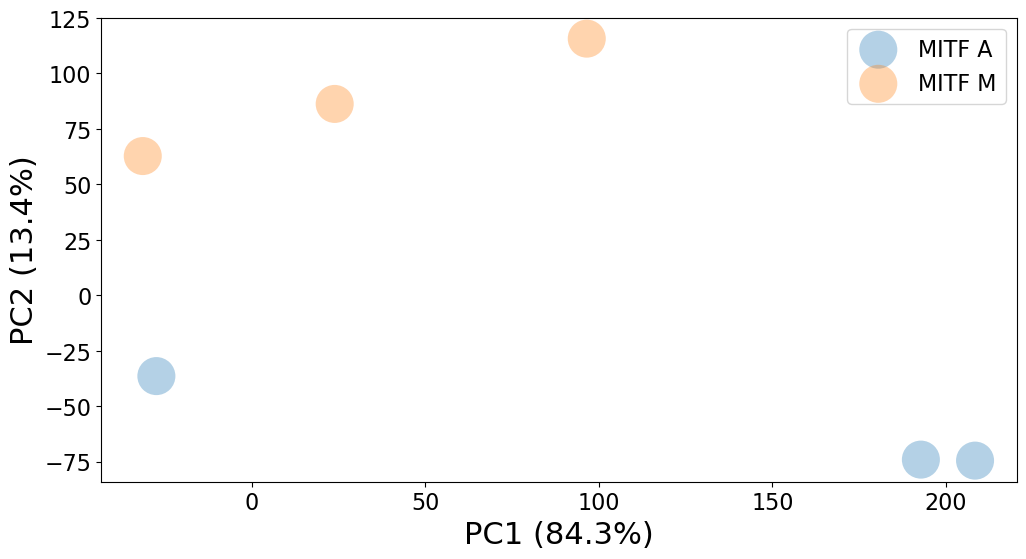

In [11]:
is_A = pca_df.index.str.contains("_A_")
is_M = pca_df.index.str.contains("_M_")

matplotlib.pyplot.scatter(
    pca_df.loc[is_A, "PC1"],
    pca_df.loc[is_A, "PC2"],
    s=750,
    alpha=1/3,
    color="tab:blue",
    edgecolors="none",
    label="MITF A"
)

matplotlib.pyplot.scatter(
    pca_df.loc[is_M, "PC1"],
    pca_df.loc[is_M, "PC2"],
    s=750,
    alpha=1/3,
    color="tab:orange",
    edgecolors="none",
    label="MITF M"
)

matplotlib.pyplot.xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)",
    fontsize=22
)
matplotlib.pyplot.ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)",
    fontsize=22
)

matplotlib.pyplot.xticks(fontsize=16)
matplotlib.pyplot.yticks(fontsize=16)

matplotlib.pyplot.legend(fontsize=16)
matplotlib.pyplot.tight_layout()
matplotlib.pyplot.show()

